In [2]:
import os

DATASET_PATH = "/kaggle/input/datasets/balajis11556/raildataset/rail defects detection.v18i.yolov8"

for root, dirs, files in os.walk(DATASET_PATH):
    level = root.replace(DATASET_PATH, "").count(os.sep)
    indent = "    " * level
    print(f"{indent}{os.path.basename(root)}/")

    for file in files[:5]:
        print(f"{indent}    {file}")

    if level >= 2:
        dirs[:] = []

rail defects detection.v18i.yolov8/
    valid/
        labels/
            20231018_114843_mp4-0129_jpg.rf.055b12a76fb46d1d9ab3f875d8bbba2f.txt
            VID-20231018-WA0017_mp4-0198_jpg.rf.cfba4afc8ecafeba94f12028489d861c.txt
            20231018_114952_mp4-0156_jpg.rf.2308572d2661721a9e3448cda6657fb4.txt
            20231018_114843_mp4-0163_jpg.rf.e9552f9087827759da523bbe543fcfec.txt
            VID-20231018-WA0024_mp4-0058_jpg.rf.874706aee3f60b5e61b02b0e16ee3aa5.txt
        images/
            VID-20231018-WA0010_mp4-0192_jpg.rf.8540dbf089f6fcf84d0b01f274fcb893.jpg
            VID-20231018-WA0010_mp4-0036_jpg.rf.f48235ce9dbbe92c3a1f3b410160b79d.jpg
            20231018_112728_mp4-0164_jpg.rf.232cd96b23aac3216aad34c51cd3b52c.jpg
            VID-20231018-WA0005_mp4-0291_jpg.rf.255753f4efc943b72cc9ce50e35437cb.jpg
            VID-20231018-WA0009_mp4-0154_jpg.rf.cab8ff8799eadf820f0be0417ad7475f.jpg
    test/
        labels/
            Rail_1_mp4-0138_jpg.rf.2c20dc2635b6d8f449dec7a73c

In [4]:
import os

print("Files in dataset root:")

for file in os.listdir(DATASET_PATH):
    print(file)

Files in dataset root:
valid
test
train


In [5]:
from collections import Counter
import os

label_counts = Counter()

for split in ["train", "valid", "test"]:
    label_dir = os.path.join(DATASET_PATH, split, "labels")

    for file in os.listdir(label_dir):
        if file.endswith(".txt"):
            with open(os.path.join(label_dir, file), "r") as f:
                for line in f:
                    parts = line.strip().split()

                    if parts:
                        class_id = int(parts[0])
                        label_counts[class_id] += 1

print("Class ID counts:")
for class_id, count in sorted(label_counts.items()):
    print(f"Class {class_id}: {count}")

Class ID counts:
Class 0: 138
Class 1: 6060
Class 2: 4884
Class 3: 4799
Class 4: 396
Class 5: 510
Class 6: 6246
Class 7: 4951
Class 8: 3668
Class 9: 4058


In [4]:
import os

label_dir = os.path.join(DATASET_PATH, "train", "labels")

shown = 0

for file in os.listdir(label_dir):
    if file.endswith(".txt"):
        path = os.path.join(label_dir, file)

        with open(path, "r") as f:
            lines = f.readlines()

        print(f"\n{file}")
        for line in lines[:5]:
            print(line.strip())

        shown += 1

        if shown >= 5:
            break


VID-20231018-WA0024_mp4-0086_jpg.rf.5a92ae5194bafb8c8a71ff6018f2875b.txt
1 0.8375 0.41328125 0.075 0.25
9 0.9390625 0.315625 0.121875 0.4
8 0.946875 0.3671875 0.10625 0.0796875
8 0.934375 0.27734375 0.103125 0.053125
1 0.8625 0.18671875 0.075 0.178125

20231018_113518_mp4-0179_jpg.rf.27f1f9be66bc3929166272bdf6cc8990.txt
6 0.7575524452079959 0.4918998999338869 0.05490767589344294 0.04653416327441153
3 0.5451903439525826 0.8138479002725711 0.11609452669174569 0.1323764880142125
8 0.54597425254582 0.7754438195398765 0.060775673916276675 0.03748671189493056
2 0.481056201176676 0.9307321850982803 0.02815417490485981 0.04045458163720568
3 0.7094797707602467 0.07318137494422917 0.11606003460041095 0.14636274988845835

VID-20231018-WA0013_mp4-0146_jpg.rf.68e5c1bc0b9d4408bbdb3f3ffed9c775.txt
6 0.9375 0.475 0.04609375 0.07734375
6 0.909375 0.578125 0.04609375 0.06796875
8 0.79375 0.671875 0.20859375 0.209375

20231018_120709_mp4-0089_jpg.rf.f8724e6ab914dc389e6014d6d89072cb.txt
1 0.6399636821745

In [5]:
import os

for split in ["train", "valid", "test"]:
    image_dir = os.path.join(DATASET_PATH, split, "images")
    label_dir = os.path.join(DATASET_PATH, split, "labels")

    print(f"{split}:")
    print("Images:", len(os.listdir(image_dir)))
    print("Labels:", len(os.listdir(label_dir)))
    print()

train:
Images: 6781
Labels: 6691

valid:
Images: 606
Labels: 616

test:
Images: 310
Labels: 310



In [7]:
import os

for split in ["train", "valid", "test"]:
    image_dir = os.path.join(DATASET_PATH, split, "images")
    label_dir = os.path.join(DATASET_PATH, split, "labels")

    images = {
        os.path.splitext(f)[0]
        for f in os.listdir(image_dir)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    }

    labels = {
        os.path.splitext(f)[0]
        for f in os.listdir(label_dir)
        if f.endswith(".txt")
    }

    missing_labels = images - labels
    orphan_labels = labels - images

    print(f"\n--- {split.upper()} ---")
    print("Images without labels:", len(missing_labels))
    print("Labels without images:", len(orphan_labels))

    if missing_labels:
        print("\nImages without labels:")
        for x in sorted(missing_labels)[:10]:
            print(x)

    if orphan_labels:
        print("\nLabels without images:")
        for x in sorted(orphan_labels)[:10]:
            print(x)


--- TRAIN ---
Images without labels: 100
Labels without images: 10

Images without labels:
20231018_114952_mp4-0242_jpg.rf.297fb67deb8fd334c5ca36ae10dbef49(1)
20231018_114952_mp4-0242_jpg.rf.ec1e0cbe672436fe8f135b2c0fd40b95(1)
20231018_114952_mp4-0243_jpg.rf.a0b1b457ca7b80dce248eea84d9238a1(1)
20231018_114952_mp4-0243_jpg.rf.e5b9c25d1663e242645f9abb13875c02(1)
20231018_114952_mp4-0243_jpg.rf.febd04b9ab91bed7d6b80ca80f054cf7(1)
20231018_114952_mp4-0244_jpg.rf.26986db60c879e3a32291ad01ec8e968(1)
20231018_114952_mp4-0244_jpg.rf.6f934448e54cb52aebb3dd4cfb904a3b(1)
20231018_114952_mp4-0244_jpg.rf.92687ebd8fff3b22af4c6cedd612c51f(1)
20231018_114952_mp4-0246_jpg.rf.594562ad6c7003208bd90ec515ff0719(1)
20231018_114952_mp4-0246_jpg.rf.d16b903edc8c205826a519ee83953c6e(1)

Labels without images:
20231018_114952_mp4-0566_jpg.rf.89bb77a9bc0f1b7bdafccf2b176eaa8b(1)
20231018_114952_mp4-0566_jpg.rf.97cd6b1f78929769bc03c809664298e5(1)
20231018_114952_mp4-0566_jpg.rf.e585c0494f11c334eee9a4340e618a8a(1)


In [9]:
import os
from collections import Counter

IMAGE_EXTS = (".jpg", ".jpeg", ".png", ".bmp", ".webp")

for split in ["train", "valid", "test"]:

    image_dir = os.path.join(DATASET_PATH, split, "images")
    label_dir = os.path.join(DATASET_PATH, split, "labels")

    image_files = [
        f for f in os.listdir(image_dir)
        if f.lower().endswith(IMAGE_EXTS)
    ]

    label_files = [
        f for f in os.listdir(label_dir)
        if f.endswith(".txt")
    ]

    image_map = {
        os.path.splitext(f)[0]: f
        for f in image_files
    }

    label_map = {
        os.path.splitext(f)[0]: f
        for f in label_files
    }

    missing_labels = set(image_map) - set(label_map)
    orphan_labels = set(label_map) - set(image_map)

    invalid_labels = []
    empty_labels = []
    invalid_class_ids = []
    invalid_coordinates = []

    class_counts = Counter()
    total_objects = 0

    for label_file in label_files:

        path = os.path.join(label_dir, label_file)

        with open(path, "r") as f:
            lines = [line.strip() for line in f if line.strip()]

        if not lines:
            empty_labels.append(label_file)
            continue

        for line_no, line in enumerate(lines, start=1):

            parts = line.split()

            if len(parts) != 5:
                invalid_labels.append(
                    (label_file, line_no, line)
                )
                continue

            try:
                class_id = int(parts[0])
                x, y, w, h = map(float, parts[1:])
            except ValueError:
                invalid_labels.append(
                    (label_file, line_no, line)
                )
                continue

            if class_id < 0 or class_id > 9:
                invalid_class_ids.append(
                    (label_file, line_no, class_id)
                )

            if not all(0 <= v <= 1 for v in [x, y, w, h]):
                invalid_coordinates.append(
                    (label_file, line_no, [x, y, w, h])
                )

            class_counts[class_id] += 1
            total_objects += 1

    print("=" * 60)
    print(f"{split.upper()} DATASET AUDIT")
    print("=" * 60)

    print(f"Images:                {len(image_files)}")
    print(f"Labels:                {len(label_files)}")
    print(f"Images without labels: {len(missing_labels)}")
    print(f"Orphan labels:         {len(orphan_labels)}")
    print(f"Empty labels:          {len(empty_labels)}")
    print(f"Invalid label rows:    {len(invalid_labels)}")
    print(f"Invalid class IDs:     {len(invalid_class_ids)}")
    print(f"Invalid coordinates:   {len(invalid_coordinates)}")
    print(f"Total objects:         {total_objects}")

    print("\nClass distribution:")

    for class_id in range(10):
        print(
            f"Class {class_id}: "
            f"{class_counts[class_id]}"
        )

TRAIN DATASET AUDIT
Images:                6781
Labels:                6691
Images without labels: 100
Orphan labels:         10
Empty labels:          25
Invalid label rows:    0
Invalid class IDs:     0
Invalid coordinates:   0
Total objects:         31263

Class distribution:
Class 0: 138
Class 1: 5241
Class 2: 4199
Class 3: 4231
Class 4: 363
Class 5: 480
Class 6: 5501
Class 7: 4341
Class 8: 3208
Class 9: 3561
VALID DATASET AUDIT
Images:                606
Labels:                616
Images without labels: 0
Orphan labels:         10
Empty labels:          6
Invalid label rows:    0
Invalid class IDs:     0
Invalid coordinates:   0
Total objects:         2892

Class distribution:
Class 0: 0
Class 1: 509
Class 2: 434
Class 3: 398
Class 4: 22
Class 5: 22
Class 6: 477
Class 7: 417
Class 8: 312
Class 9: 301
TEST DATASET AUDIT
Images:                310
Labels:                310
Images without labels: 10
Orphan labels:         10
Empty labels:          3
Invalid label rows:    0
Invalid 

In [6]:
import os
import shutil

SOURCE = DATASET_PATH
OUTPUT = "/kaggle/working/railway_defect_binary"

splits = ["train", "valid", "test"]

for split in splits:

    src_images = os.path.join(SOURCE, split, "images")
    src_labels = os.path.join(SOURCE, split, "labels")

    out_images = os.path.join(OUTPUT, split, "images")
    out_labels = os.path.join(OUTPUT, split, "labels")

    os.makedirs(out_images, exist_ok=True)
    os.makedirs(out_labels, exist_ok=True)

    copied = 0
    empty = 0
    missing = 0

    for image_file in os.listdir(src_images):

        if not image_file.lower().endswith(
            (".jpg", ".jpeg", ".png", ".bmp", ".webp")
        ):
            continue

        image_name = os.path.splitext(image_file)[0]
        label_file = image_name + ".txt"
        label_path = os.path.join(src_labels, label_file)

        # Copy image
        shutil.copy2(
            os.path.join(src_images, image_file),
            os.path.join(out_images, image_file)
        )

        copied += 1

        # Missing label
        if not os.path.exists(label_path):
            missing += 1
            continue

        new_lines = []

        with open(label_path, "r") as f:
            for line in f:
                parts = line.strip().split()

                if len(parts) == 5:
                    parts[0] = "0"
                    new_lines.append(" ".join(parts))

        # Create label file only when annotations exist
        if new_lines:
            with open(
                os.path.join(out_labels, label_file), "w"
            ) as f:
                f.write("\n".join(new_lines) + "\n")
        else:
            empty += 1

    print(f"\n{split.upper()}")
    print(f"Images copied:        {copied}")
    print(f"Empty labels:         {empty}")
    print(f"Missing labels:       {missing}")

print("\nBinary dataset:")
print(OUTPUT)


TRAIN
Images copied:        6781
Empty labels:         25
Missing labels:       100

VALID
Images copied:        606
Empty labels:         6
Missing labels:       0

TEST
Images copied:        310
Empty labels:         3
Missing labels:       10

Binary dataset:
/kaggle/working/railway_defect_binary


In [13]:
for split in ["train", "valid", "test"]:

    image_dir = os.path.join(OUTPUT, split, "images")
    label_dir = os.path.join(OUTPUT, split, "labels")

    print(
        split,
        "→ Images:", len(os.listdir(image_dir)),
        "| Label files:", len(os.listdir(label_dir))
    )

train → Images: 6781 | Label files: 6656
valid → Images: 606 | Label files: 600
test → Images: 310 | Label files: 297


In [14]:
import os

yaml_path = "/kaggle/working/railway_defect_binary/data.yaml"

yaml_content = f"""path: {OUTPUT}
train: train/images
val: valid/images
test: test/images

nc: 1
names:
  0: defect
"""

with open(yaml_path, "w") as f:
    f.write(yaml_content)

print("data.yaml created:")
print(yaml_path)

print("\nContents:\n")
print(yaml_content)

data.yaml created:
/kaggle/working/railway_defect_binary/data.yaml

Contents:

path: /kaggle/working/railway_defect_binary
train: train/images
val: valid/images
test: test/images

nc: 1
names:
  0: defect



In [7]:
!pip install -q ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 20.8 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.0/96.0 kB 3.7 MB/s eta 0:00:00


In [8]:
import ultralytics

print("Ultralytics version:", ultralytics.__version__)

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
Ultralytics version: 8.4.172


In [19]:
from ultralytics import YOLO

model = YOLO("yolo11n.pt")

print("YOLO11 loaded successfully!")

YOLO11 loaded successfully!


In [20]:
results = model.train(
    data="/kaggle/working/railway_defect_binary/data.yaml",
    epochs=50,
    imgsz=640,
    batch=16,
    device=0,
    project="/kaggle/working/railway_yolo11",
    name="yolo11n_defect",
    pretrained=True,
    patience=10,
    workers=2
)

Ultralytics 8.4.172 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/railway_defect_binary/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo11n_defect, nbs=64, nms=None, opset=N

/usr/local/lib/python3.13/dist-packages/ray/train/_internal/session.py:683: UserWarning: `get_trial_id` is meant to only be called inside a function that is executed by a Tuner or Trainer. Returning `None`.
  warnings.warn(


       2/50      2.85G      2.493      2.514      1.905         76        640: 100% ━━━━━━━━━━━━ 424/424 8.9it/s 47.5s0.1ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 19/19 5.5it/s 3.4s0.2s
                   all        606       2838       0.23      0.191      0.128     0.0408

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       3/50      2.85G      2.465      2.456       1.89         69        640: 100% ━━━━━━━━━━━━ 424/424 8.8it/s 48.3s0.1sss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 19/19 5.6it/s 3.4s0.2s
                   all        606       2838      0.211      0.215      0.123     0.0382

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       4/50      2.85G      2.419      2.395      1.851         84        640: 100% ━━━━━━━━━━━━ 424/424 8.7it/s 49.0s0.2ss
                 Class     Im

In [10]:
import os

paths = [
    "/kaggle/working/railway_yolo11/yolo11n_defect/weights/best.pt",
    "/kaggle/working/railway_yolo11/yolo11n_defect/weights/last.pt",
    "/kaggle/working/railway_defect_binary/data.yaml"
]

for path in paths:
    print(path, "→", os.path.exists(path))

/kaggle/working/railway_yolo11/yolo11n_defect/weights/best.pt → False
/kaggle/working/railway_yolo11/yolo11n_defect/weights/last.pt → False
/kaggle/working/railway_defect_binary/data.yaml → False


In [11]:
import os

DATASET_PATH = "/kaggle/input/datasets/balajis11556/raildataset/rail defects detection.v18i.yolov8"

print(os.listdir(DATASET_PATH))

['valid', 'test', 'train']


In [12]:
import os
import shutil

SOURCE = DATASET_PATH
OUTPUT = "/kaggle/working/railway_defect_binary"

splits = ["train", "valid", "test"]

for split in splits:
    src_images = os.path.join(SOURCE, split, "images")
    src_labels = os.path.join(SOURCE, split, "labels")

    out_images = os.path.join(OUTPUT, split, "images")
    out_labels = os.path.join(OUTPUT, split, "labels")

    os.makedirs(out_images, exist_ok=True)
    os.makedirs(out_labels, exist_ok=True)

    copied = 0
    empty = 0
    missing = 0

    for image_file in os.listdir(src_images):

        if not image_file.lower().endswith(
            (".jpg", ".jpeg", ".png", ".bmp", ".webp")
        ):
            continue

        image_name = os.path.splitext(image_file)[0]
        label_file = image_name + ".txt"
        label_path = os.path.join(src_labels, label_file)

        shutil.copy2(
            os.path.join(src_images, image_file),
            os.path.join(out_images, image_file)
        )

        copied += 1

        if not os.path.exists(label_path):
            missing += 1
            continue

        new_lines = []

        with open(label_path, "r") as f:
            for line in f:
                parts = line.strip().split()

                if len(parts) == 5:
                    parts[0] = "0"
                    new_lines.append(" ".join(parts))

        if new_lines:
            with open(
                os.path.join(out_labels, label_file), "w"
            ) as f:
                f.write("\n".join(new_lines) + "\n")
        else:
            empty += 1

    print(f"{split.upper()}")
    print(f"Images copied: {copied}")
    print(f"Empty labels: {empty}")
    print(f"Missing labels: {missing}")
    print()

print("Binary dataset recreated:")
print(OUTPUT)

TRAIN
Images copied: 6781
Empty labels: 25
Missing labels: 100

VALID
Images copied: 606
Empty labels: 6
Missing labels: 0

TEST
Images copied: 310
Empty labels: 3
Missing labels: 10

Binary dataset recreated:
/kaggle/working/railway_defect_binary


In [13]:
import os

for split in ["train", "valid", "test"]:
    image_dir = os.path.join(OUTPUT, split, "images")
    label_dir = os.path.join(OUTPUT, split, "labels")

    print(
        split.upper(),
        "→ Images:", len(os.listdir(image_dir)),
        "| Label files:", len(os.listdir(label_dir))
    )

TRAIN → Images: 6781 | Label files: 6656
VALID → Images: 606 | Label files: 600
TEST → Images: 310 | Label files: 297


In [14]:
yaml_path = "/kaggle/working/railway_defect_binary/data.yaml"

yaml_content = f"""path: {OUTPUT}
train: train/images
val: valid/images
test: test/images

nc: 1
names:
  0: defect
"""

with open(yaml_path, "w") as f:
    f.write(yaml_content)

print(yaml_content)

path: /kaggle/working/railway_defect_binary
train: train/images
val: valid/images
test: test/images

nc: 1
names:
  0: defect



In [15]:
import ultralytics
print(ultralytics.__version__)

8.4.172


In [16]:
from ultralytics import YOLO

model = YOLO("yolo11n.pt")

print("YOLO11 loaded successfully!")

YOLO11 loaded successfully!


In [17]:
results = model.train(
    data="/kaggle/working/railway_defect_binary/data.yaml",
    epochs=50,
    imgsz=640,
    batch=16,
    device=0,
    project="/kaggle/working/railway_yolo11",
    name="yolo11n_defect",
    pretrained=True,
    patience=10,
    workers=2
)

Ultralytics 8.4.172 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/railway_defect_binary/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo11n_defect, nbs=64, nms=None, opset=N

/usr/local/lib/python3.13/dist-packages/ray/train/_internal/session.py:683: UserWarning: `get_trial_id` is meant to only be called inside a function that is executed by a Tuner or Trainer. Returning `None`.
  warnings.warn(


       2/50      2.85G      2.493      2.514      1.905         76        640: 100% ━━━━━━━━━━━━ 424/424 7.5it/s 56.7s0.1ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 19/19 4.9it/s 3.9s0.2s
                   all        606       2838       0.23      0.191      0.128     0.0408

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       3/50      2.85G      2.465      2.456       1.89         69        640: 100% ━━━━━━━━━━━━ 424/424 7.6it/s 56.0s0.1ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 19/19 5.1it/s 3.7s0.2s
                   all        606       2838      0.211      0.215      0.123     0.0382

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       4/50      2.85G      2.419      2.395      1.851         84        640: 100% ━━━━━━━━━━━━ 424/424 7.6it/s 56.0s0.1ss
                 Class     Ima

In [18]:
import os

best_path = "/kaggle/working/railway_yolo11/yolo11n_defect/weights/best.pt"

print("Exists:", os.path.exists(best_path))

if os.path.exists(best_path):
    print("Size:", round(os.path.getsize(best_path) / (1024 * 1024), 2), "MB")

Exists: True
Size: 5.22 MB


In [19]:
test_results = model.val(
    data="/kaggle/working/railway_defect_binary/data.yaml",
    split="test",
    imgsz=640,
    batch=16,
    device=0,
    project="/kaggle/working/railway_yolo11",
    name="test_results"
)

Ultralytics 8.4.172 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
YOLO11n summary (fused): 100 layers, 2,582,347 parameters, 0 gradients, 6.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1358.2±333.1 MB/s, size: 65.2 KB)
val: Scanning /kaggle/working/railway_defect_binary/test/labels... 297 images, 13 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 310/310 991.2it/s 0.3s0.0s
val: New cache created: /kaggle/working/railway_defect_binary/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 20/20 4.5it/s 4.5s0.1s
                   all        310       1494      0.477      0.406        0.4      0.144
Speed: 1.9ms preprocess, 5.6ms inference, 0.0ms loss, 2.2ms postprocess per image
Results saved to /kaggle/working/railway_yolo11/test_results


In [20]:
import shutil
import os

best_path = "/kaggle/working/railway_yolo11/yolo11n_defect/weights/best.pt"

backup_path = "/kaggle/working/YOLO11_railway_defect_best.pt"

shutil.copy2(best_path, backup_path)

print("Backup created:")
print(backup_path)
print("Size:", round(os.path.getsize(backup_path) / (1024 * 1024), 2), "MB")

Backup created:
/kaggle/working/YOLO11_railway_defect_best.pt
Size: 5.22 MB


In [22]:
from ultralytics import YOLO

best_model = YOLO(
    "/kaggle/working/railway_yolo11/yolo11n_defect/weights/best.pt"
)

print("Best YOLO11 model loaded!")

Best YOLO11 model loaded!


In [23]:
predictions = best_model.predict(
    source="/kaggle/working/railway_defect_binary/test/images",
    imgsz=640,
    conf=0.25,
    device=0,
    save=True,
    project="/kaggle/working/railway_yolo11",
    name="test_predictions"
)

print("Predictions completed!")


image 1/310 /kaggle/working/railway_defect_binary/test/images/20231018_112728_mp4-0004_jpg.rf.741e9c5216c788ffb0fb417b518e6f5e.jpg: 640x640 2 defects, 8.9ms
image 2/310 /kaggle/working/railway_defect_binary/test/images/20231018_112728_mp4-0017_jpg.rf.65cfc2df1e656f0edafb62455a36daca.jpg: 640x640 3 defects, 10.4ms
image 3/310 /kaggle/working/railway_defect_binary/test/images/20231018_112728_mp4-0039_jpg.rf.ef4853efcf0393ab32f1be54f91cf6c6.jpg: 640x640 7 defects, 9.8ms
image 4/310 /kaggle/working/railway_defect_binary/test/images/20231018_112728_mp4-0042_jpg.rf.702ed1aa2759e00bd4be588cab600735.jpg: 640x640 8 defects, 9.5ms
image 5/310 /kaggle/working/railway_defect_binary/test/images/20231018_112728_mp4-0045_jpg.rf.e1fd06f785c644cace10527e1f94dc99.jpg: 640x640 5 defects, 11.2ms
image 6/310 /kaggle/working/railway_defect_binary/test/images/20231018_112728_mp4-0106_jpg.rf.7748e8d5e975549523149d871a9e297e.jpg: 640x640 7 defects, 10.0ms
image 7/310 /kaggle/working/railway_defect_binary/test

Prediction images: 310
20231018_112728_mp4-0214_jpg.rf.56f3f591495243dbb3f823786c603227.jpg


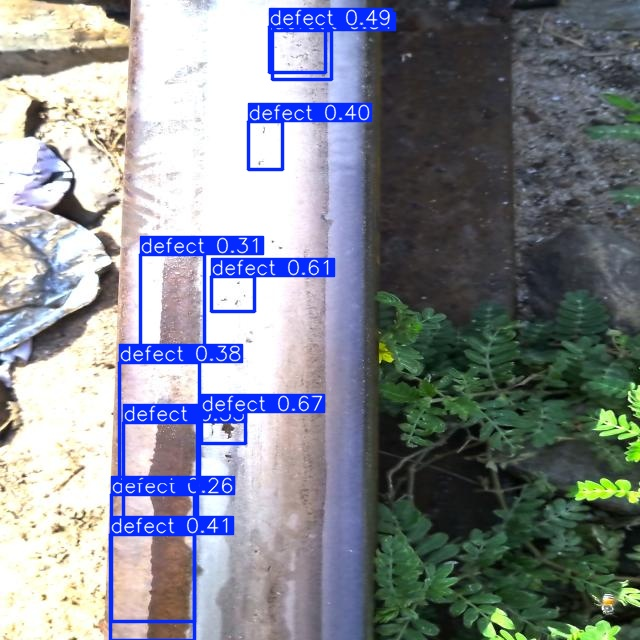

20231018_113043_mp4-0081_jpg.rf.13dc3ed591956459df961b86fb86f6ec.jpg


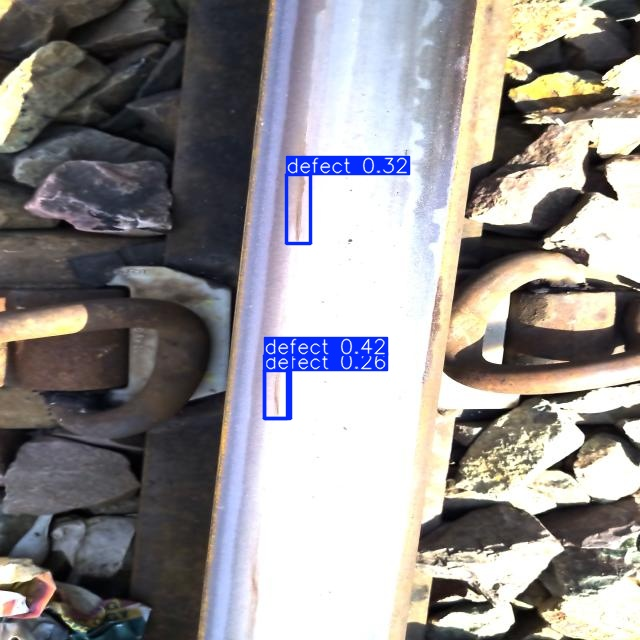

20231018_114952_mp4-0336_jpg.rf.7de90355d120bca635dd8ed3f2aa274c.jpg


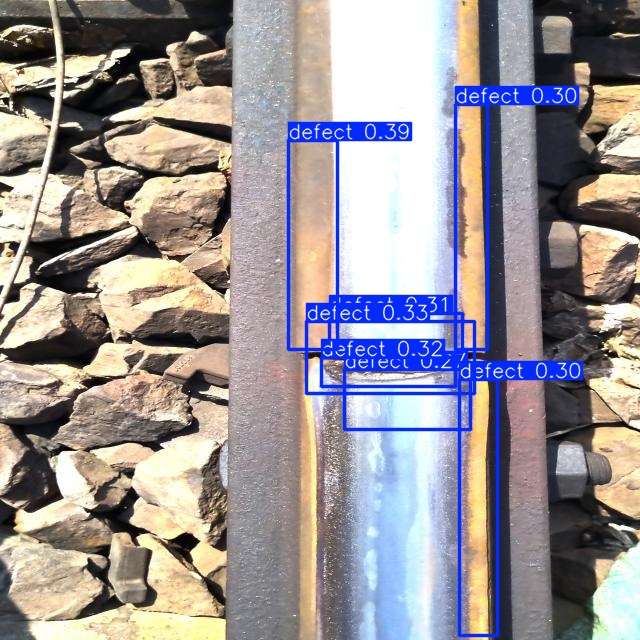

20231018_113043_mp4-0004_jpg.rf.65014ebd6188bcbfd6d8de9b22cf4b89.jpg


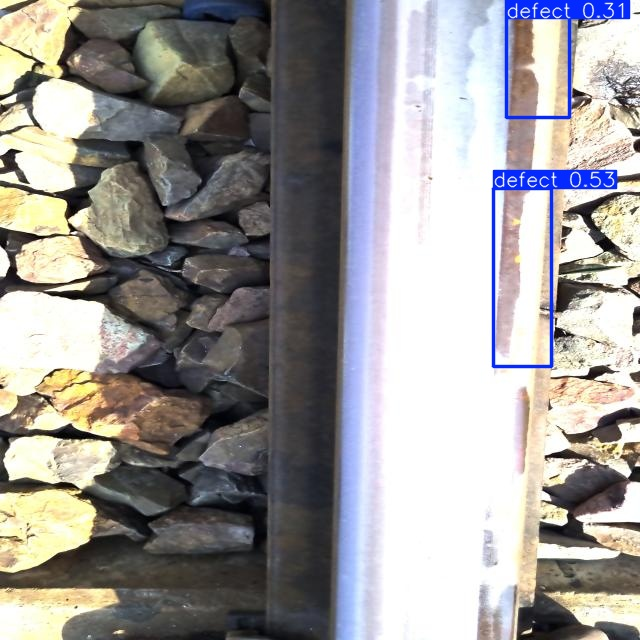

VID-20231018-WA0014_mp4-0181_jpg.rf.add180af6d4f29dda55d008bb76b9b88.jpg


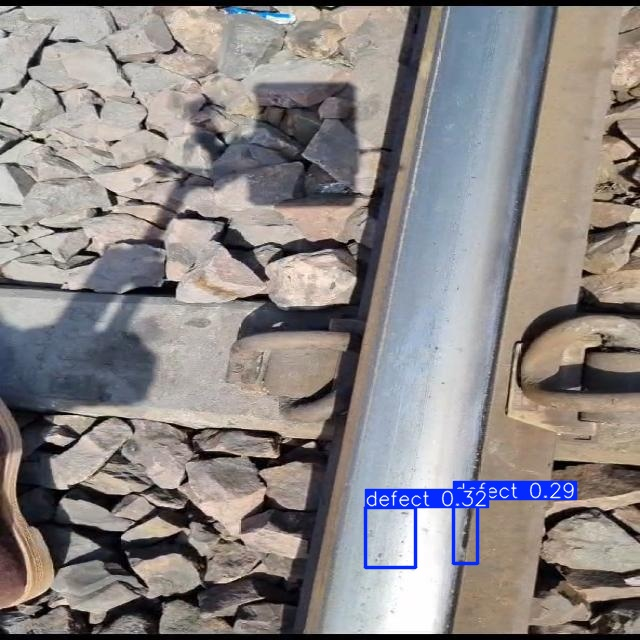

VID-20231018-WA0010_mp4-0185_jpg.rf.12cd28ec55ffaef138551e1a6e22250e.jpg


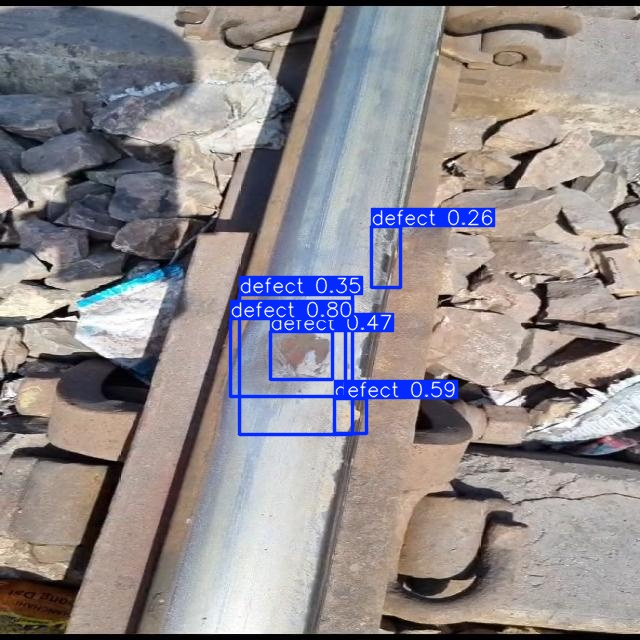

In [24]:
from IPython.display import display, Image
import os

pred_dir = "/kaggle/working/railway_yolo11/test_predictions"

files = [
    f for f in os.listdir(pred_dir)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]

print("Prediction images:", len(files))

for f in files[:6]:
    print(f)
    display(Image(filename=os.path.join(pred_dir, f)))

In [25]:
predictions = best_model.predict(
    source="/kaggle/working/railway_defect_binary/test/images",
    imgsz=640,
    conf=0.50,
    device=0,
    save=True,
    project="/kaggle/working/railway_yolo11",
    name="test_predictions_conf50"
)

print("Confidence 0.50 predictions completed!")


image 1/310 /kaggle/working/railway_defect_binary/test/images/20231018_112728_mp4-0004_jpg.rf.741e9c5216c788ffb0fb417b518e6f5e.jpg: 640x640 (no detections), 12.6ms
image 2/310 /kaggle/working/railway_defect_binary/test/images/20231018_112728_mp4-0017_jpg.rf.65cfc2df1e656f0edafb62455a36daca.jpg: 640x640 1 defect, 10.2ms
image 3/310 /kaggle/working/railway_defect_binary/test/images/20231018_112728_mp4-0039_jpg.rf.ef4853efcf0393ab32f1be54f91cf6c6.jpg: 640x640 1 defect, 10.7ms
image 4/310 /kaggle/working/railway_defect_binary/test/images/20231018_112728_mp4-0042_jpg.rf.702ed1aa2759e00bd4be588cab600735.jpg: 640x640 2 defects, 10.3ms
image 5/310 /kaggle/working/railway_defect_binary/test/images/20231018_112728_mp4-0045_jpg.rf.e1fd06f785c644cace10527e1f94dc99.jpg: 640x640 (no detections), 14.0ms
image 6/310 /kaggle/working/railway_defect_binary/test/images/20231018_112728_mp4-0106_jpg.rf.7748e8d5e975549523149d871a9e297e.jpg: 640x640 (no detections), 11.7ms
image 7/310 /kaggle/working/railway

In [26]:
import os
import shutil
import pandas as pd

BASE = "/kaggle/working/YOLO11"

# Create folders
os.makedirs(BASE, exist_ok=True)
os.makedirs(f"{BASE}/results", exist_ok=True)
os.makedirs(f"{BASE}/predictions/confidence_50", exist_ok=True)

# -------------------------
# 1. MODEL
# -------------------------
shutil.copy(
    "/kaggle/working/YOLO11_railway_defect_best.pt",
    f"{BASE}/YOLO11_railway_defect_best.pt"
)

# -------------------------
# 2. TRAINING LOG
# -------------------------
train_csv = "/kaggle/working/railway_yolo11/yolo11n_defect/results.csv"

if os.path.exists(train_csv):
    shutil.copy(
        train_csv,
        f"{BASE}/training_log.csv"
    )

# -------------------------
# 3. TRAINING RESULTS
# -------------------------
train_results = "/kaggle/working/railway_yolo11/yolo11n_defect"

for file in [
    "results.png",
    "confusion_matrix.png",
    "labels.jpg",
    "PR_curve.png",
    "F1_curve.png",
    "P_curve.png",
    "R_curve.png"
]:
    src = os.path.join(train_results, file)
    if os.path.exists(src):
        shutil.copy(src, f"{BASE}/results/{file}")

# -------------------------
# 4. TEST RESULTS
# -------------------------
test_results = "/kaggle/working/railway_yolo11/test_results"

if os.path.exists(test_results):
    shutil.copytree(
        test_results,
        f"{BASE}/results/test_results",
        dirs_exist_ok=True
    )

# -------------------------
# 5. FINAL PREDICTIONS
# -------------------------
predictions = "/kaggle/working/railway_yolo11/test_predictions_conf50"

if os.path.exists(predictions):
    shutil.copytree(
        predictions,
        f"{BASE}/predictions/confidence_50",
        dirs_exist_ok=True
    )

print("✅ YOLO11 folder created!")
print(BASE)

✅ YOLO11 folder created!
/kaggle/working/YOLO11


In [27]:
!du -sh /kaggle/working/YOLO11

51M	/kaggle/working/YOLO11


In [28]:
!find /kaggle/working/YOLO11 -maxdepth 3 -type f | sort

/kaggle/working/YOLO11/predictions/confidence_50/20231018_112728_mp4-0004_jpg.rf.741e9c5216c788ffb0fb417b518e6f5e.jpg
/kaggle/working/YOLO11/predictions/confidence_50/20231018_112728_mp4-0017_jpg.rf.65cfc2df1e656f0edafb62455a36daca.jpg
/kaggle/working/YOLO11/predictions/confidence_50/20231018_112728_mp4-0039_jpg.rf.ef4853efcf0393ab32f1be54f91cf6c6.jpg
/kaggle/working/YOLO11/predictions/confidence_50/20231018_112728_mp4-0042_jpg.rf.702ed1aa2759e00bd4be588cab600735.jpg
/kaggle/working/YOLO11/predictions/confidence_50/20231018_112728_mp4-0045_jpg.rf.e1fd06f785c644cace10527e1f94dc99.jpg
/kaggle/working/YOLO11/predictions/confidence_50/20231018_112728_mp4-0106_jpg.rf.7748e8d5e975549523149d871a9e297e.jpg
/kaggle/working/YOLO11/predictions/confidence_50/20231018_112728_mp4-0121_jpg.rf.36e3b8f422d0d68744edbabacdc4869f.jpg
/kaggle/working/YOLO11/predictions/confidence_50/20231018_112728_mp4-0123_jpg.rf.27b83619906fc59778f349635d22adf0.jpg
/kaggle/working/YOLO11/predictions/confidence_50/2023101

In [29]:
import os
import shutil
import glob

export_dir = "/kaggle/working/YOLO11_GitHub"

os.makedirs(export_dir, exist_ok=True)
os.makedirs(f"{export_dir}/results/predictions", exist_ok=True)

# Best model
shutil.copy(
    "/kaggle/working/YOLO11_railway_defect_best.pt",
    f"{export_dir}/YOLO11_railway_defect_best.pt"
)

# Training results
run_dir = "/kaggle/working/railway_yolo11/yolo11n_defect"

for file in ["results.csv", "results.png", "confusion_matrix.png"]:
    src = os.path.join(run_dir, file)
    if os.path.exists(src):
        shutil.copy(src, f"{export_dir}/results/{file}")

# Test results
test_dir = "/kaggle/working/railway_yolo11/test_results"

for file in ["confusion_matrix.png", "results.png"]:
    src = os.path.join(test_dir, file)
    if os.path.exists(src):
        shutil.copy(src, f"{export_dir}/results/test_" + file)

# Copy a few prediction examples
pred_dir = "/kaggle/working/railway_yolo11/test_predictions_conf50"

images = glob.glob(pred_dir + "/*.jpg")[:10]

for i, img in enumerate(images, 1):
    shutil.copy(
        img,
        f"{export_dir}/results/predictions/prediction_{i:02d}.jpg"
    )

print("YOLO11 export folder created:")
print(export_dir)

for root, dirs, files in os.walk(export_dir):
    for file in files:
        print(os.path.join(root, file))

YOLO11 export folder created:
/kaggle/working/YOLO11_GitHub
/kaggle/working/YOLO11_GitHub/YOLO11_railway_defect_best.pt
/kaggle/working/YOLO11_GitHub/results/results.png
/kaggle/working/YOLO11_GitHub/results/results.csv
/kaggle/working/YOLO11_GitHub/results/confusion_matrix.png
/kaggle/working/YOLO11_GitHub/results/test_confusion_matrix.png
/kaggle/working/YOLO11_GitHub/results/predictions/prediction_04.jpg
/kaggle/working/YOLO11_GitHub/results/predictions/prediction_08.jpg
/kaggle/working/YOLO11_GitHub/results/predictions/prediction_09.jpg
/kaggle/working/YOLO11_GitHub/results/predictions/prediction_10.jpg
/kaggle/working/YOLO11_GitHub/results/predictions/prediction_07.jpg
/kaggle/working/YOLO11_GitHub/results/predictions/prediction_03.jpg
/kaggle/working/YOLO11_GitHub/results/predictions/prediction_01.jpg
/kaggle/working/YOLO11_GitHub/results/predictions/prediction_06.jpg
/kaggle/working/YOLO11_GitHub/results/predictions/prediction_05.jpg
/kaggle/working/YOLO11_GitHub/results/predict

In [30]:
import shutil

zip_path = shutil.make_archive(
    "/kaggle/working/YOLO11_GitHub",
    "zip",
    "/kaggle/working/YOLO11_GitHub"
)

print(zip_path)

/kaggle/working/YOLO11_GitHub.zip
